In [4]:
import pandas as pd
df = pd.read_csv('/content/data_k_mean.txt', header = None, sep = ' ',names = ['X', 'Y'])
df

,X,Y
0,-7.87157,-4.86573
1,-4.76661,-6.87944
2,-6.67986,-5.83080
3,-8.93021,-4.15571
4,-7.91375,-4.22840
...,...,...
2995,-8.06037,-4.84080
2996,7.47328,0.37321
2997,6.91832,-0.32132
2998,-8.23828,-4.00405


In [5]:
k = 2

In [7]:
c1 = df.iloc[200, :].values
c2 = df.iloc[500, :].values
c1, c2

(array([5.67849, 2.28385]), array([-9.11147, -5.0321 ]))

In [14]:
while True:
  df['distance_from_c1'] = (df['X'] - c1[0])**2 + (df['Y'] - c1[1])**2
  df['distance_from_c2'] = (df['X'] - c2[0])**2 + (df['Y'] - c2[1])**2
  df['group'] = df[['distance_from_c1', 'distance_from_c2']].apply(lambda x: 1 if x[0]<x[1] else 2,  axis = 1)
  new_c1 = df[df['group'] == 1][['X', 'Y']].mean().values
  new_c2 = df[df['group'] == 2][['X', 'Y']].mean().values
  if (new_c1==c1).all() and (new_c2==c2).all():
    break
  c1 = new_c1
  c2 = new_c2

<ipython-input-14-dccba417c22b>:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df['group'] = df[['distance_from_c1', 'distance_from_c2']].apply(lambda x: 1 if x[0]<x[1] else 2,  axis = 1)


In [15]:
df

,X,Y,distance_from_c1,distance_from_c2,group
0,-7.87157,-4.86573,259.603029,1.843153,2
1,-4.76661,-6.87944,202.338151,5.546806,2
2,-6.67986,-5.83080,236.890186,0.030922,2
3,-8.93021,-4.15571,285.157204,6.914930,2
4,-7.91375,-4.22840,254.084878,3.430061,2
...,...,...,...,...,...
2995,-8.06037,-4.84080,265.055635,2.320228,2
2996,7.47328,0.37321,0.232223,241.352193,1
2997,6.91832,-0.32132,1.307603,217.816368,1
2998,-8.23828,-4.00405,261.813925,4.967172,2


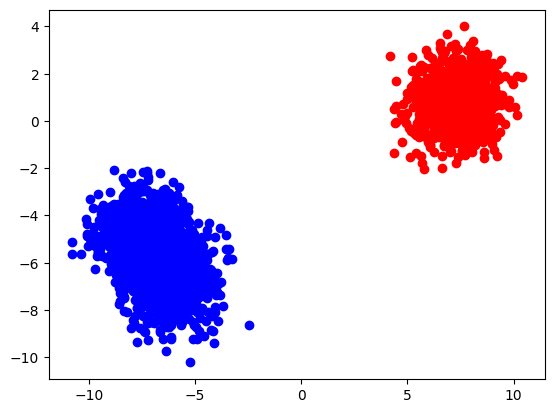

In [16]:
import matplotlib.pyplot as plt

plt.scatter(df[df['group'] == 1]['X'], df[df['group'] == 1]['Y'], color = 'red')
plt.scatter(df[df['group'] == 2]['X'], df[df['group'] == 2]['Y'], color = 'blue')